# Calculate Propensity Score

In [1]:
import pandas as pd
import os
from psmpy import PsmPy
from psmpy.functions import cohenD
from psmpy.plotting import *
import seaborn as sns

In [2]:
run_local = True

if run_local:
    path_data = '../data/clean_data/'
else:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_path = '/content/drive/My Drive/Pol pub Proyecto - shared/Datos/'
    path_data = drive_path

In [3]:
# Leemos los datos
data = pd.read_parquet(os.path.join(path_data, 'propensity_score_features.parquet'))

In [4]:
# Creamos el objeto que se encarga del propensity score y del matching
exclude = ['sin_accidentes', 'Vehiculo desbarrancado', 'Persona atropellada', 'Un sentido con carril de contraflujo'] #, 'Vehículo atrapadovarado']
psm = PsmPy(data, treatment='has_camera', indx='grid_id', exclude = exclude)

In [5]:
# Calculamos el propensity score
psm.logistic_ps(balance = True)

In [6]:
# Utilizamos algún algoritmo de matching
# Versión 1: KNN
if False:
    psm.knn_matched(
        matcher='propensity_logit', # specifies the argument on which matching will proceed
        replacement=True, # determines whether macthing will happen with or without replacement
                           # when replacement is False, matching will happen 1:1
        caliper=None, # specify caliper size relative to std dev of the control sample, 
                      # restricting neighbors eligible to match within a certain distance
                      # (si se limita, puede haber tratados para los cuales no haya match, y se tirarían)
        drop_unmatched=True
    )

In [7]:
# Versión 2: KNN 1 to many
if True:
    psm.knn_matched_12n(
        matcher='propensity_logit', 
        how_many=2
    )

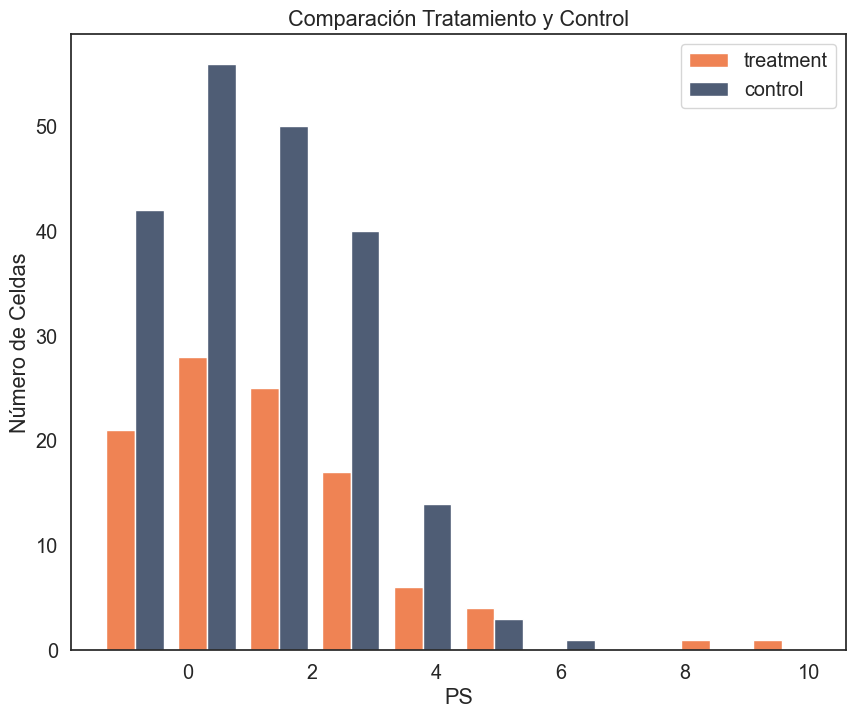

In [8]:
# Podemos graficar los resultados
# Ahora graficamos la distribución de los propensity logits

color_tratado = '#ef8354'
color_control = '#4f5d75'

psm.plot_match(
    Title='Comparación Tratamiento y Control', 
    Ylabel='Número de Celdas', 
    Xlabel= 'PS', 
    names = ['treatment', 'control'], 
    colors=[color_tratado, color_control],
    save=True
)

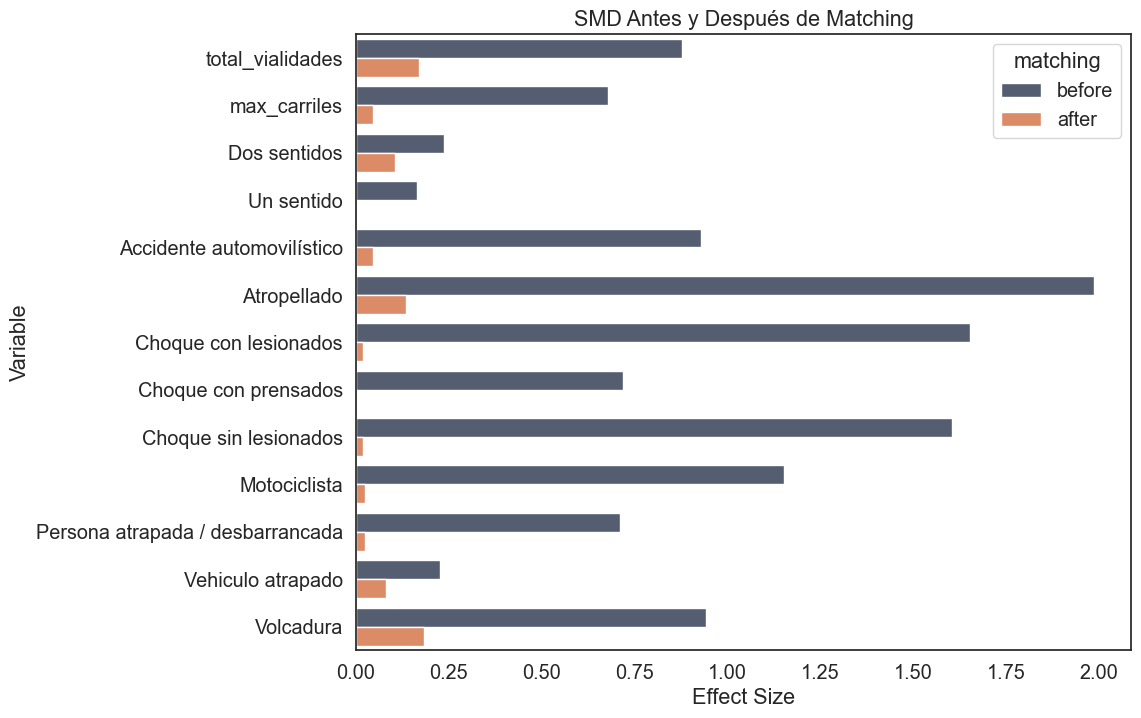

In [9]:
psm.effect_size_plot(
    title='SMD Antes y Después de Matching', 
    before_color=color_control, 
    after_color=color_tratado, 
    save=True
)

In [10]:
treated_ids = psm.matched_ids[['grid_id']]
# control_ids = psm.matched_ids[['matched_ID']].rename({'matched_ID':'grid_id'}, axis=1)
control_ids = pd.DataFrame(psm.matched_ids.drop(['grid_id'], axis=1).values.reshape(-1)).rename({0:'grid_id'}, axis=1)

In [14]:
# Guardamos los tratados y los controles en un parquet
(
    treated_ids
    .assign(type='treated')
    .pipe(
        lambda df_treated:
        control_ids
        .assign(type='control')
        .pipe(
            lambda df_control:
            pd.concat((df_treated, df_control), ignore_index=True)
        )
    )
    .to_parquet(os.path.join(path_data, 'matched_data.parquet'), index=False)
)

In [12]:
drop_cols = ['grid_id', 'has_camera', 'sin_accidentes']
drop_cols.extend(exclude)
variables = data.drop(drop_cols, axis=1).columns

In [13]:
# Vamos a graficar la distribución de los dos a ver cómo se ven
for variable in variables:
    print(variable)
    fig, axes = plt.subplots(1,2, figsize=(8, 4), sharey=False)
    
    for ax in axes:
        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)
    
    color_tratado = '#ef8354'
    color_control = '#4f5d75'
    
    # Graficamos las distribuciones originales
    ax = axes[0]
    sns.kdeplot(data.query('has_camera')[variable], ax=ax, color=color_tratado, fill=True)
    sns.kdeplot(data.query('~has_camera')[variable], ax=ax, color=color_control, fill=True)
    
    ax.set_title('Before Matching', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set(xlabel=None)
    ax.set_ylabel('Densidad', fontsize=10, labelpad=10)
    
    # Graficamos los que ya están matcheados
    ax = axes[1]
    sns.kdeplot(data.merge(treated_ids, on='grid_id', how='inner')[variable], ax=ax, label='Tratado', color=color_tratado, fill=True)
    sns.kdeplot(data.merge(control_ids, on='grid_id', how='inner')[variable], ax=ax, label='Control', color=color_control, fill=True)
    
    ax.set(xlabel=None, ylabel=None)
    ax.legend(fontsize=10)
    ax.set_title('After Matching', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    fig.suptitle(f'Variable | {variable}', fontsize=15)
    fig.tight_layout()
    fig.savefig(f'{os.path.join(path_data, "images/variable-distributions", variable.replace("/", "").lower().replace(" ", "_"))}.png', dpi=300, transparent=True)
    plt.close()

total_vialidades
max_carriles
Dos sentidos
Un sentido
Accidente automovilístico
Atropellado
Choque con lesionados
Choque con prensados
Choque sin lesionados
Motociclista
Persona atrapada / desbarrancada
Vehiculo atrapado
Volcadura
